# Validate LATER Assumptions
The LATER model [1-2] assumes saccade latencies are inverse-Gaussian: $T = T_{sac} + T_{err}$ where $T_{sac} ≈ \frac{1}{r}$ and $r ~ \mathcal{N}(μ, σ^2)$. This means that when we plot saccade latencies on a reciprobit plot, they should fall roughly along a straight line.<br>
<br>
Here, we check if the data from the two experiments published in Toledano, Sasi et al. (2024) [3] meet this assumption:
1. We perform three normality tests (Shapiro-Wilk, Kolmogorov-Smirnov, Anderson-Darling) on the inverse of saccade latencies and see when they don't reject the null hypothesis of normality.
2. We check whether allowing target repeats (i.e., trials where the target appears at the same location as the previous trial) affects the normality of the inverse latencies.
3. We plot each subject's early and late saccade latencies on reciprobit plots to visually inspect the linearity.
<br>

```
CITATIONS
[1] Carpenter, R. H., & Williams, M. L. L. (1995). Neural computation of log likelihood in control of saccadic eye movements. Nature, 377(6544), 59-62.

[2] Noorani, I. (2014). LATER models of neural decision behavior in choice tasks. Frontiers in Integrative Neuroscience, 8, 67.

[3] Toledano, D., Sasi, M., Yuval-Greenberg, S., & Lamy, D. (2024). On the timing of overt attention deployment: Eye-movement evidence for the priority accumulation framework. Journal of Experimental Psychology: Human Perception and Performance, 50(5), 431.
```

In [1]:
import os
import time

import numpy as np
import pandas as pd
import scipy.stats as stats
from tqdm import tqdm
import matplotlib.pyplot as plt
import pylater

from load_data import load_and_prepare_experiments

### Prepare the Data

In [2]:
DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), "data")

data = load_and_prepare_experiments(DATA_DIR, min_condition_size=0, allow_target_repeats=True, verbose=True)

print()
print(f"Data Features: {data.columns.tolist()}")

Loaded 19833 trials from 42 subjects.
After filtering, 19833 trials remain from 42 subjects.

Data Features: ['experiment', 'subject', 'block', 'trial_in_block', 'trial', 'search_difficulty', 'target_location', 'cue_location', 'is_valid_cue', 'cue_size', 'location_distractor_map', 'saccade_onset', 'saccade_offset', 'saccade_duration', 'saccade_location', 'saccade_distractor_type', 'is_early_saccade', 'response_time', 'response_time', 'is_correct', 'prev_target_location', 'is_target_repeated', 'is_cue_at_prev_target']


### Normality Tests

In [3]:
def shapiro_wilk_normality_test(latencies: np.ndarray | pd.Series) -> tuple[float, float]:
    """ Perform a Shapiro-Wilk test to check if the inverse of latencies follows a normal distribution. """
    if isinstance(latencies, np.ndarray):
        latencies = pd.Series(latencies)
    inv_latencies = (1000 / latencies).rename("inv_latency")    # Convert to inverse latencies (1/s)
    shapiro_stat, p_value = stats.shapiro(inv_latencies)
    return shapiro_stat, p_value


def kolmogorov_smirnov_normality_test(latencies: np.ndarray | pd.Series) -> tuple[float, float]:
    """ Perform a Kolmogorov-Smirnov test to check if the inverse of latencies follows a normal distribution. """
    if isinstance(latencies, np.ndarray):
        latencies = pd.Series(latencies)
    inv_latencies = (1000 / latencies).rename("inv_latency")    # Convert to inverse latencies (1/s)
    inv_latencies = (inv_latencies - inv_latencies.mean()) / inv_latencies.std()    # Normalize
    ks_stat, p_value = stats.kstest(inv_latencies, 'norm')
    return ks_stat, p_value


def anderson_darling_normality_test(latencies: np.ndarray | pd.Series) -> tuple[float, float]:
    """ Perform an Anderson-Darling test to check if the inverse of latencies follows a normal distribution. """
    if isinstance(latencies, np.ndarray):
        latencies = pd.Series(latencies)
    inv_latencies = (1000 / latencies).rename("inv_latency")    # Convert to inverse latencies (1/s)
    ad_result = stats.anderson(inv_latencies, dist='norm')
    p_to_crit = dict(zip(ad_result.significance_level, ad_result.critical_values))
    statistic = ad_result.statistic
    p_value = min([p for p, crit in p_to_crit.items() if statistic > crit] + [50]) / 100  # Approximate p-value
    return statistic, p_value

#### Run Normality Tests

In [4]:
start = time.time()

results = dict()
for exp in data["experiment"].unique():
    exp_data = data.loc[data["experiment"] == exp]
    for subj in tqdm(exp_data["subject"].unique(), desc=f"Processing {exp}"):
        subj_data = exp_data.loc[exp_data["subject"] == subj]
        for is_early in subj_data["is_early_saccade"]:
            trial_subset = subj_data.loc[subj_data["is_early_saccade"] == is_early]
            for allow_target_repeats in [True, False]:
                if allow_target_repeats:
                    trial_subset = trial_subset
                else:
                    trial_subset = trial_subset.loc[~(trial_subset["is_target_repeated"])]
                latencies = trial_subset["saccade_onset"]
                sw_stat, sw_p = shapiro_wilk_normality_test(latencies)
                ks_stat, ks_p = kolmogorov_smirnov_normality_test(latencies)
                ad_stat, ad_p = anderson_darling_normality_test(latencies)
                results[(exp, subj, is_early, allow_target_repeats)] = {
                    "n_trials": len(latencies),
                    "sw_stat": sw_stat,
                    "sw_p": sw_p,
                    "ks_stat": ks_stat,
                    "ks_p": ks_p,
                    "ad_stat": ad_stat,
                    "ad_p": ad_p,
                }
results_df = pd.DataFrame.from_dict(results, orient="index")
results_df.index.set_names(["experiment", "subject", "is_early_saccade", "allow_target_repeats"], inplace=True)
results_df.reset_index(drop=False, inplace=True)

elapsed = time.time() - start
print(f"Normality tests completed in {elapsed:.2f} seconds.")

Processing exp_2: 100%|██████████| 25/25 [03:03<00:00,  7.33s/it]

Normality tests completed in 270.94 seconds.


##### (0) Ignore instances with low trial counts

In [5]:
TRIAL_COUNT_THRESHOLD = 20

results_df_filtered = results_df.loc[results_df["n_trials"] >= TRIAL_COUNT_THRESHOLD]
num_remaining = results_df_filtered.shape[0]
percent_remaining = (num_remaining / results_df.shape[0]) * 100
print(f"Filtered results to {num_remaining} ({percent_remaining :.1f}%) instances with at least {TRIAL_COUNT_THRESHOLD} trials.")

Filtered results to 158 (94.0%) instances with at least 20 trials.


In [6]:
SIGNIFICANCE_LEVEL = 0.05

metadata_cols = ["experiment", "subject", "is_early_saccade",]
p_cols = [col for col in results_df_filtered.columns if col.endswith("_p")]
rep_results = (
    results_df_filtered
    .loc[results_df_filtered["allow_target_repeats"], metadata_cols + p_cols]
    .apply(lambda col: col >= SIGNIFICANCE_LEVEL if col.name in p_cols else col)     # normality not rejected
    .rename(columns=lambda c: c.replace("_p", "") if c in p_cols else c)
    .set_index(metadata_cols)
)
nonrep_results = (
    results_df_filtered
    .loc[~(results_df_filtered["allow_target_repeats"]), metadata_cols + p_cols]
    .apply(lambda col: col >= SIGNIFICANCE_LEVEL if col.name in p_cols else col)     # normality not rejected
    .rename(columns=lambda c: c.replace("_p", "") if c in p_cols else c)
    .set_index(metadata_cols)
)

# check which condition yields better normality test results
frac_rep_better = (nonrep_results <= rep_results).mean(axis=0)
frac_nonrep_better = (nonrep_results >= rep_results).mean(axis=0)
tests_rep_better = [tst for tst in frac_rep_better[frac_rep_better >= frac_nonrep_better].index]
tests_nonrep_better = [tst for tst in frac_nonrep_better[frac_nonrep_better >= frac_rep_better].index]
allow_target_repeats = len(tests_rep_better) >= len(tests_nonrep_better)

print(f"{'YES' if allow_target_repeats else 'NOT'} allowing target repeats yields better normality test results when using tests: {tests_rep_better if allow_target_repeats else tests_nonrep_better}.")
print(f"We lose at most {(nonrep_results < rep_results).any(axis=1).sum()} `(subject, saccade_type)` subset(s) by excluding the opposite condition.")
print(f"To conclude, we {'DO' if allow_target_repeats else 'DO NOT'} ALLOW target repeats in the subsequent analyses.")

NOT allowing target repeats yields better normality test results when using tests: ['sw', 'ks', 'ad'].
We lose at most 3 `(subject, saccade_type)` subset(s) by excluding the opposite condition.
To conclude, we DO NOT ALLOW target repeats in the subsequent analyses.


##### (2) Summarize Normality Test Results
For each experiment we check how many subjects passed the normality tests for early and late saccades.

In [7]:
NORMALITY_TESTS = (
    results_df_filtered
    .loc[
        results_df_filtered["allow_target_repeats"] if allow_target_repeats else ~(results_df_filtered["allow_target_repeats"])
    ]
    .set_index(metadata_cols)
    .drop(columns=["allow_target_repeats"])
    .merge(
        rep_results if allow_target_repeats else nonrep_results,
        left_index=True,
        right_index=True,
        suffixes=("", "_normality_result"),
    )
)
NORMALITY_TESTS = NORMALITY_TESTS.loc[:, sorted(NORMALITY_TESTS.columns, key=lambda col: -1 if col=="n_trials" else ord(col[0]))]

In [8]:
result_cols = ["sw", "ks", "ad"]
frac_subjects_pass = NORMALITY_TESTS[result_cols].mean()
print(f"Fraction of subjects passing normality tests:\n\t{frac_subjects_pass.to_dict()}")

frac_subjects_pass_by_condition = NORMALITY_TESTS.groupby(["experiment", "is_early_saccade"])[result_cols].mean()
print(f"Fraction of subjects passing normality tests by experiment and saccade type:")
display(frac_subjects_pass_by_condition)

Fraction of subjects passing normality tests:
	{'sw': 0.189873417721519, 'ks': 0.6708860759493671, 'ad': 0.2911392405063291}
Fraction of subjects passing normality tests by experiment and saccade type:


sw        ks        ad
experiment is_early_saccade                              
exp_1      False             0.117647  0.823529  0.294118
           True              0.500000  0.857143  0.571429
exp_2      False             0.040000  0.480000  0.080000
           True              0.217391  0.652174  0.347826

##### (3) Extract Data for Further Analysis
We extract trials that comply with the following criteria:
- Only include trials where the target location adheres to the `allow_target_repeats` condition determined above.
- Of the remaining trials, only include `(subject, saccade_type)` subsets that have at least `TRIAL_COUNT_THRESHOLD` trials.

In [9]:
grouping_columns = ["experiment", "subject", "is_early_saccade"]

grouped = (
    data.loc[data["is_target_repeated"]] if allow_target_repeats else data.loc[~(data["is_target_repeated"])]
    .drop(columns=["is_target_repeated"])
    .groupby(grouping_columns)
)

num_excluded_trials = (
    grouped
    .filter(lambda grp: len(grp) < TRIAL_COUNT_THRESHOLD)
    .groupby(grouping_columns)
    .size()
    .rename("num_excluded_trials")
)
print(f"Excluding {num_excluded_trials.shape[0]} `(subject, saccade_type)` subsets with less than {TRIAL_COUNT_THRESHOLD} trials after applying the target repeat condition.")
display(num_excluded_trials.to_frame())

DATA = grouped.filter(lambda grp: len(grp) >= TRIAL_COUNT_THRESHOLD)

Excluding 5 `(subject, saccade_type)` subsets with less than 20 trials after applying the target repeat condition.


num_excluded_trials
experiment subject is_early_saccade                     
exp_1      90005   True                                6
           100029  True                                4
           100030  True                                3
exp_2      3443    True                                3
           9960    True                               13

### Reciprobit Plots
We plot reciprobit plots for each subject and saccade type to visually inspect the linearity.

In [10]:
COLORS = {"Early": "cyan", True: "cyan", "Late": "magenta", False: "magenta"}

###	Experiment 1	###


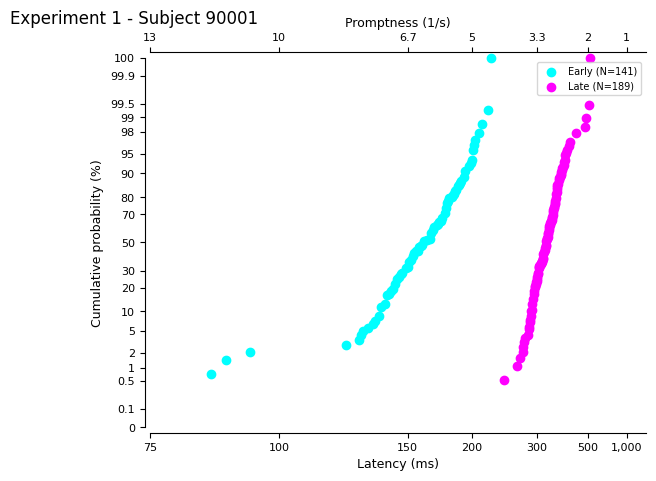

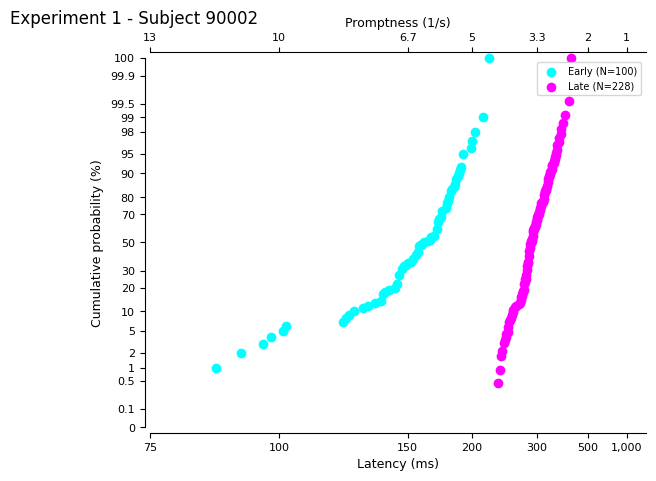

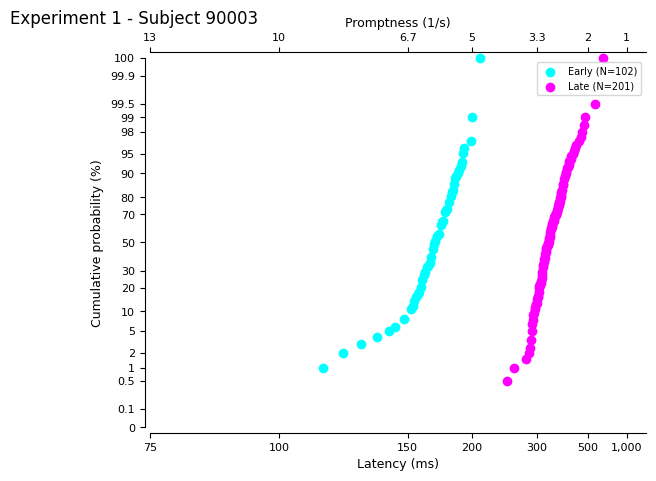

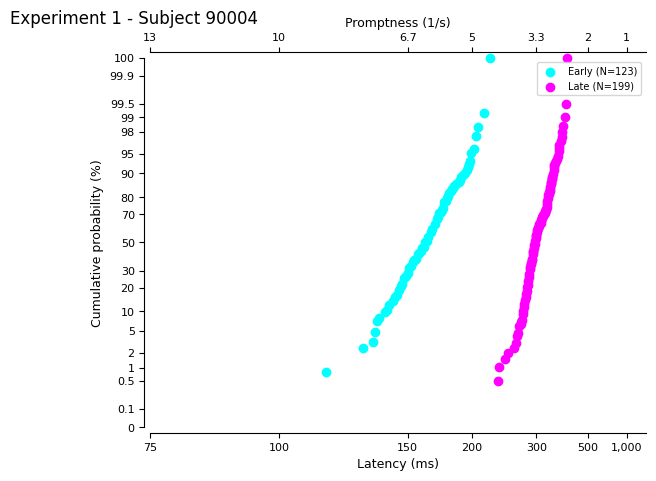

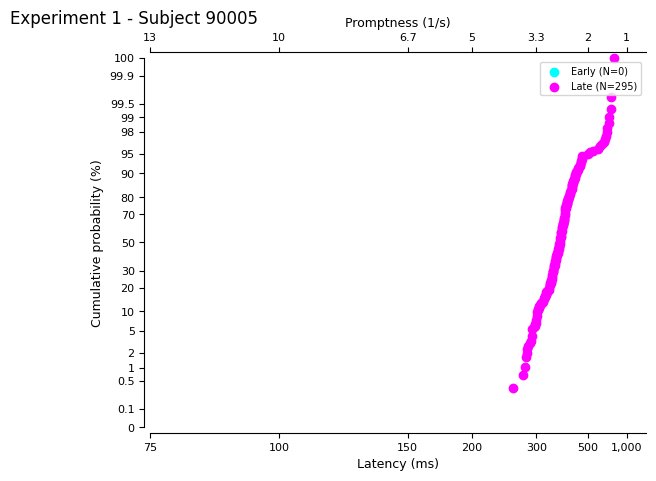

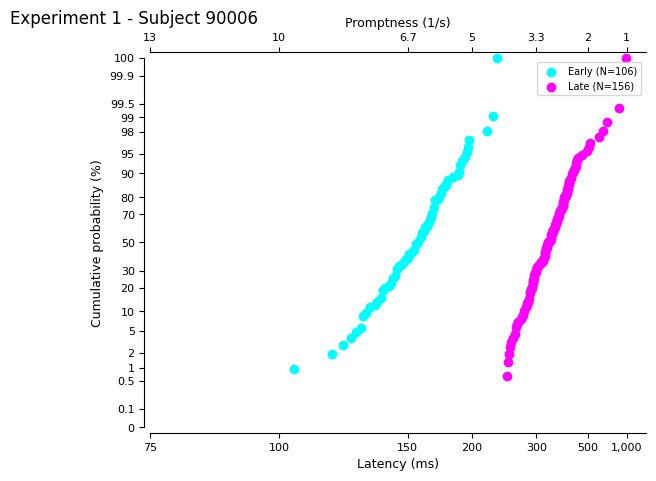

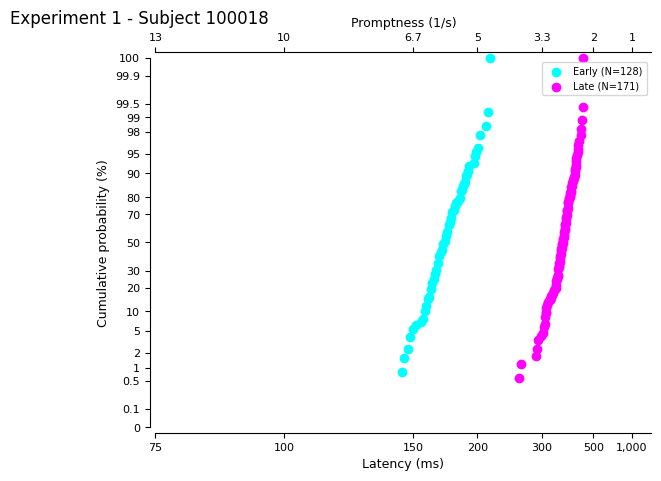

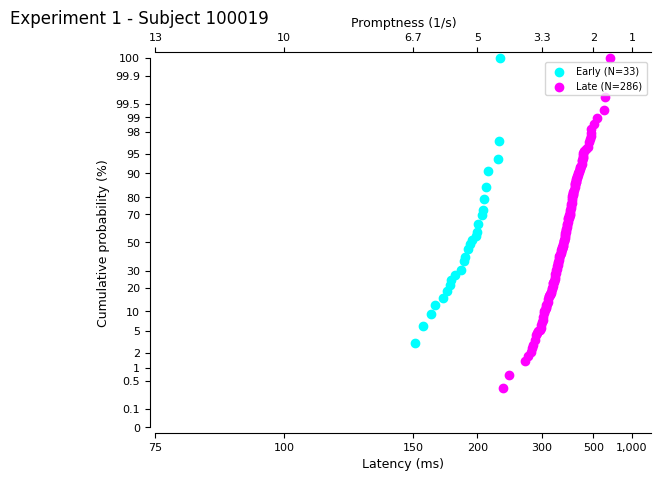

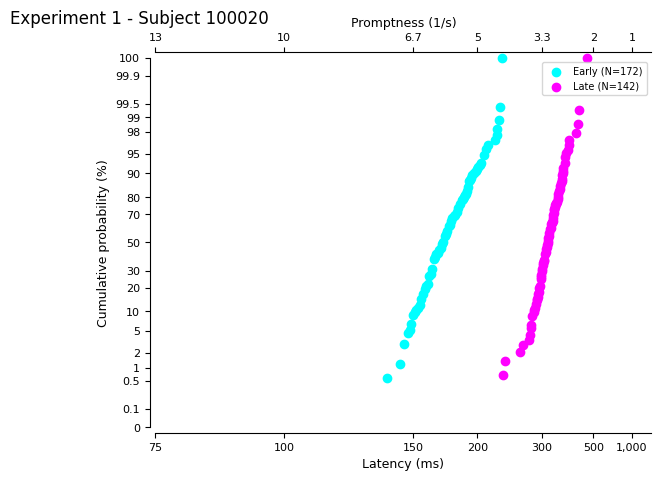

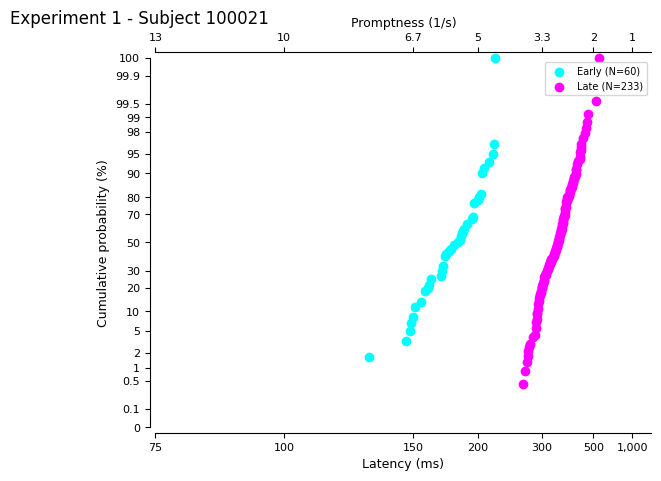

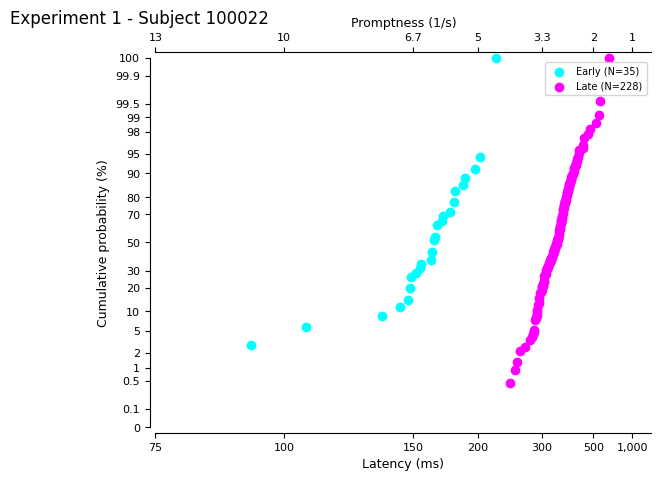

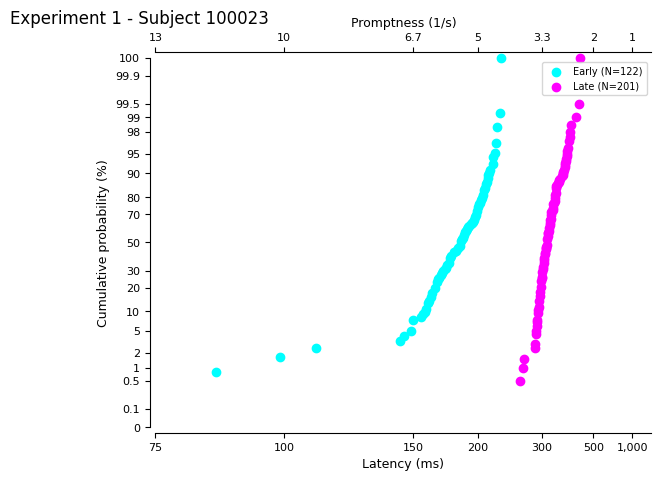

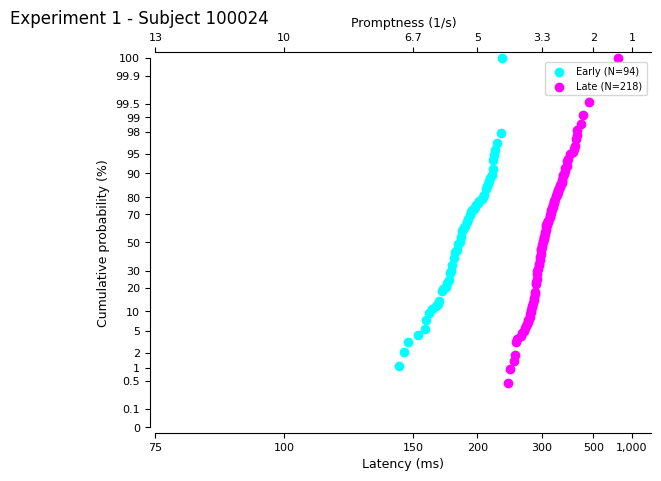

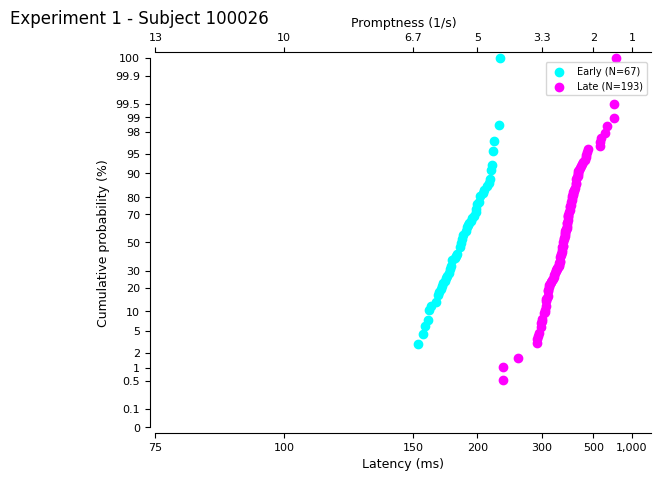

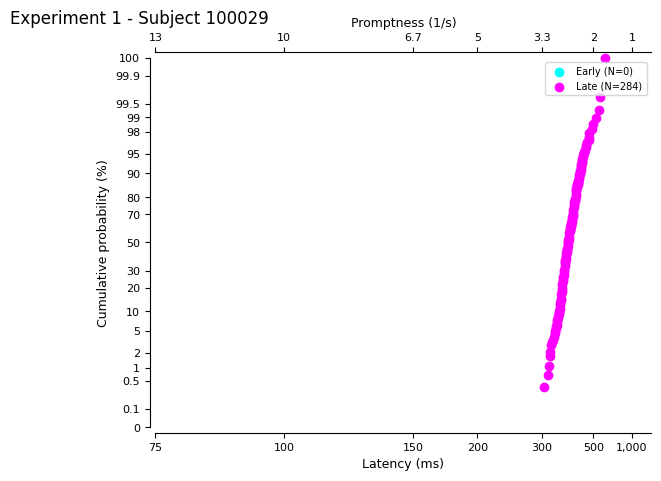

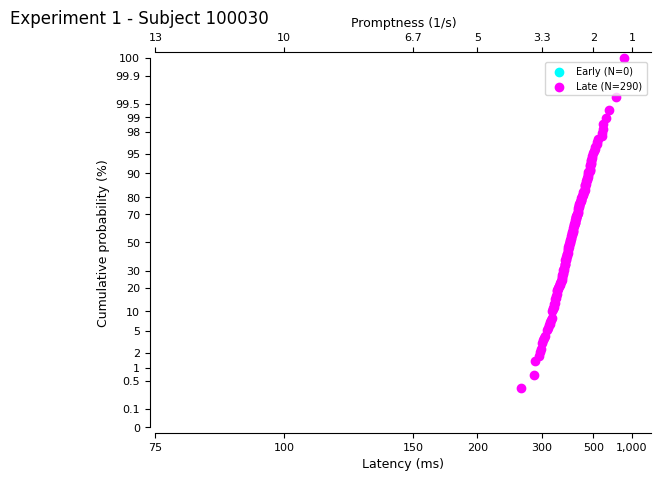

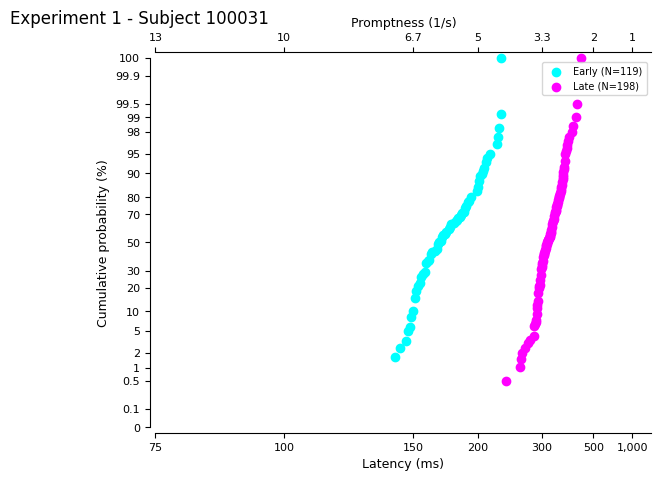


###	Experiment 2	###


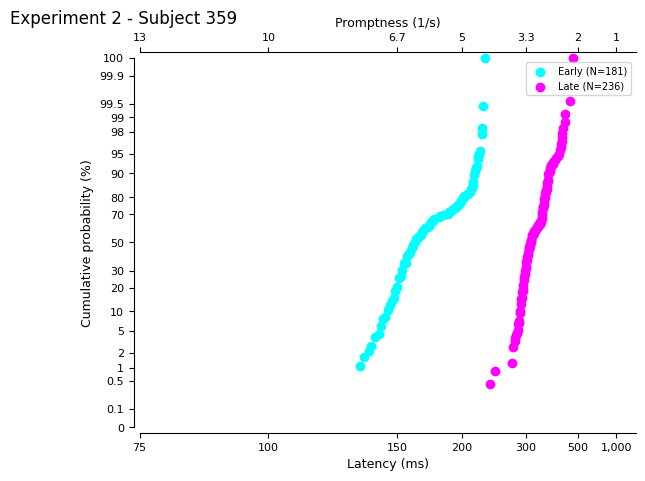

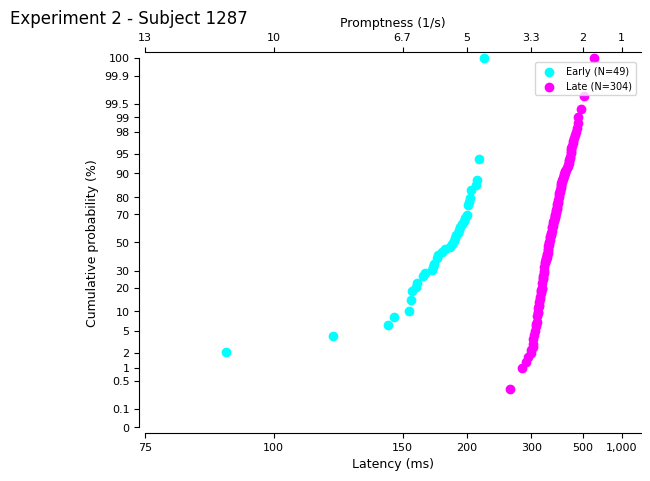

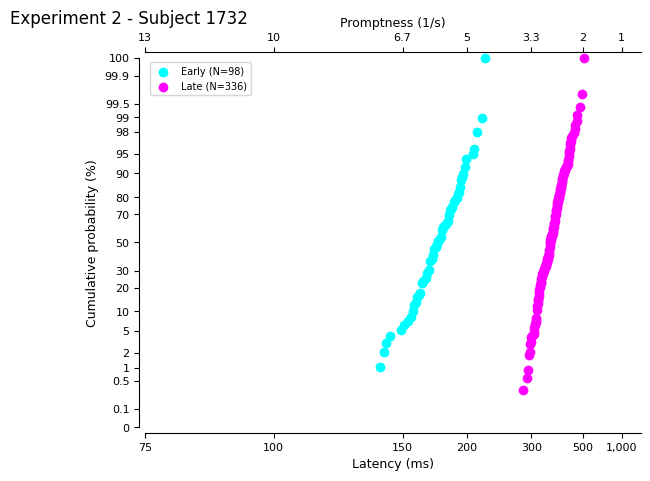

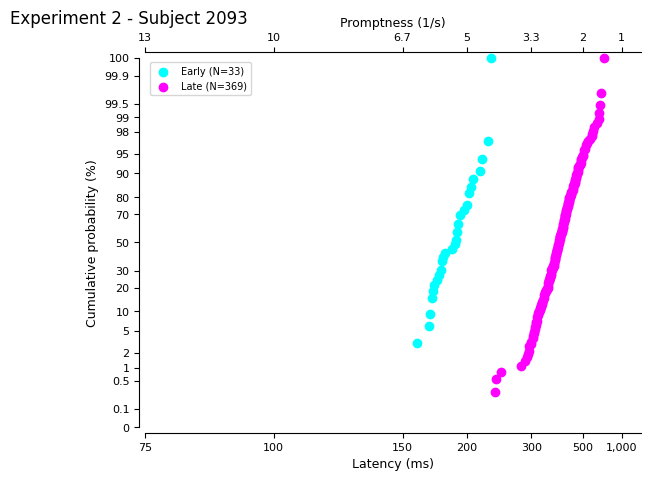

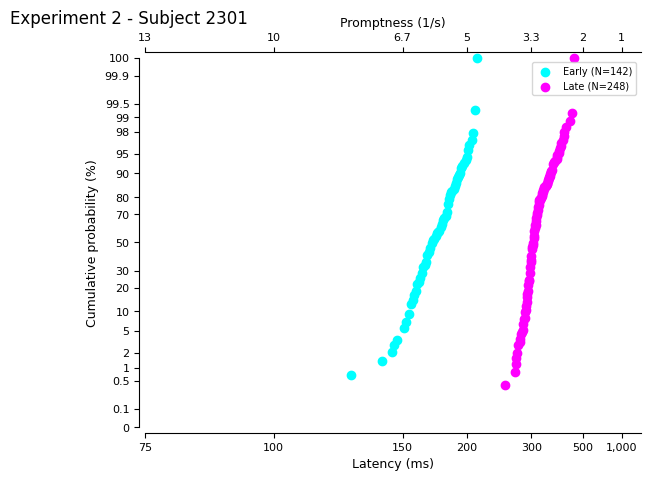

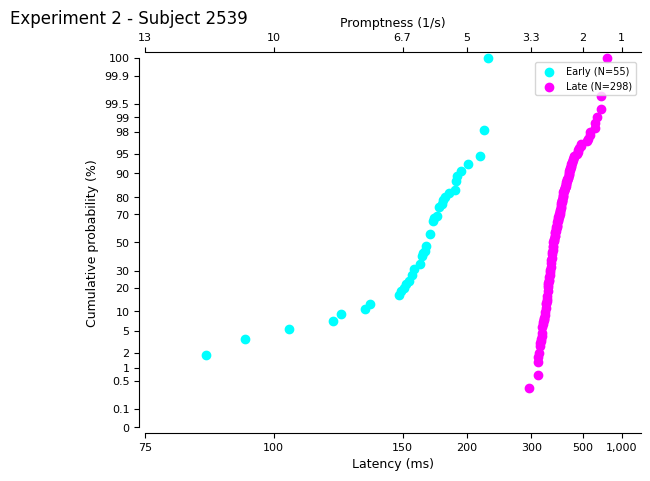

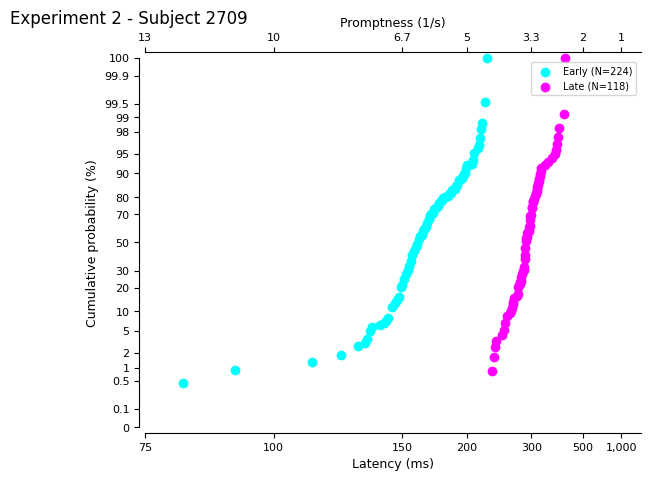

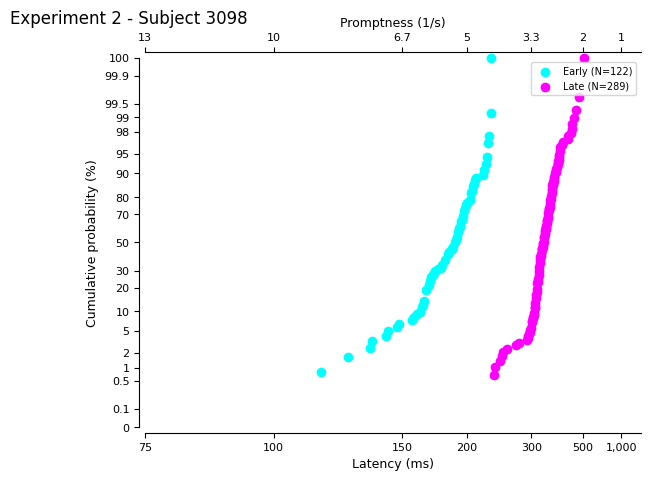

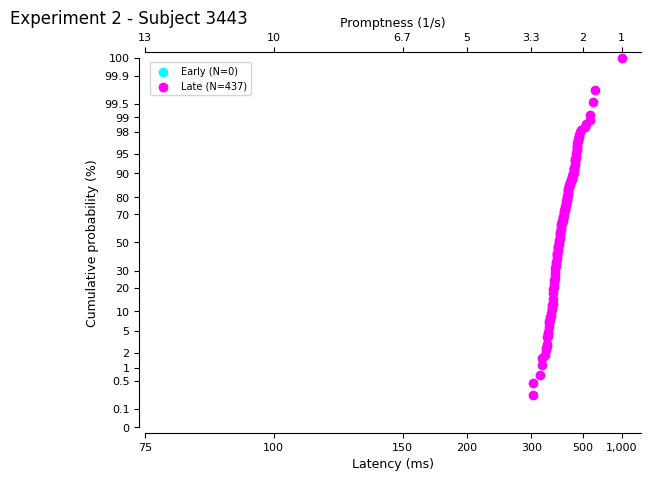

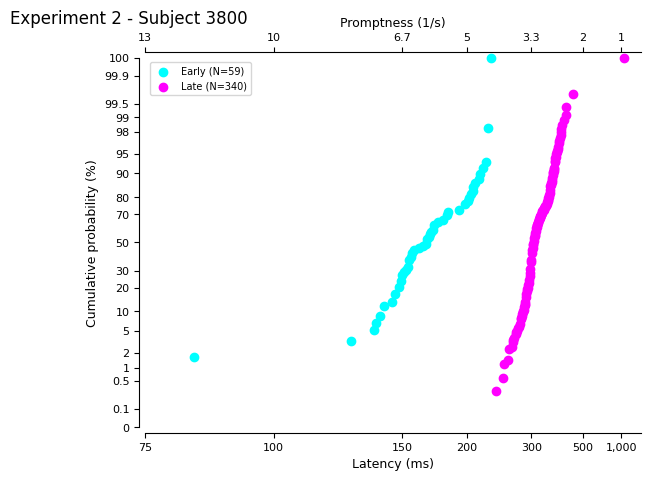

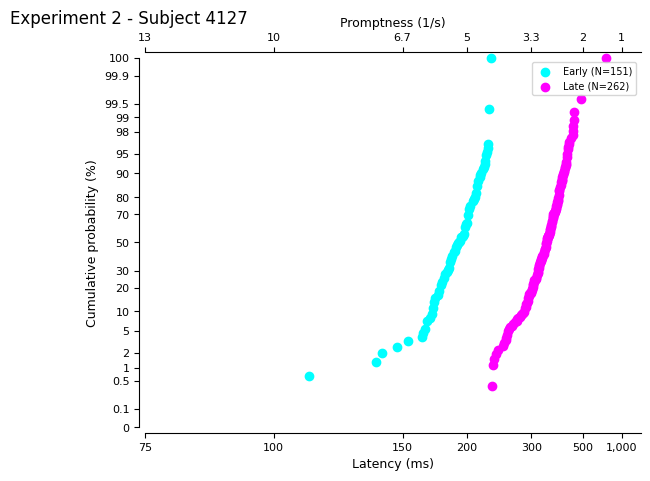

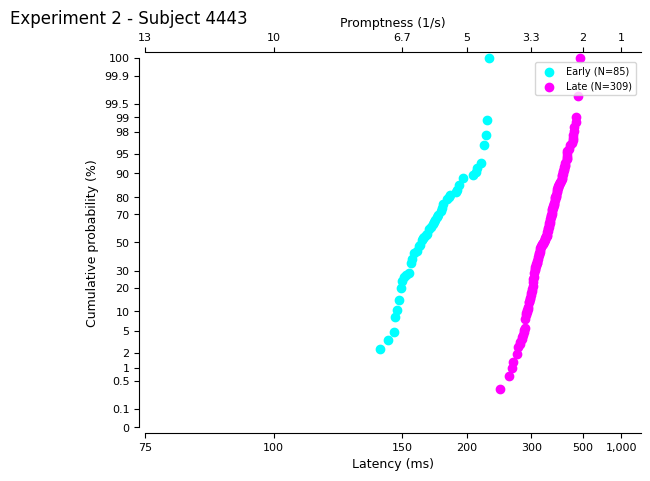

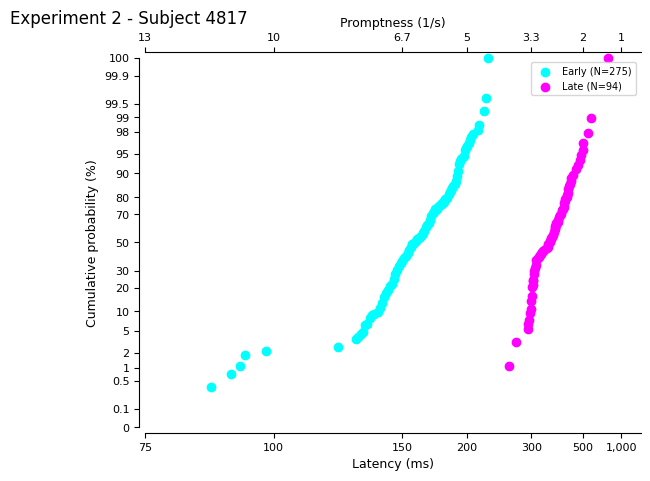

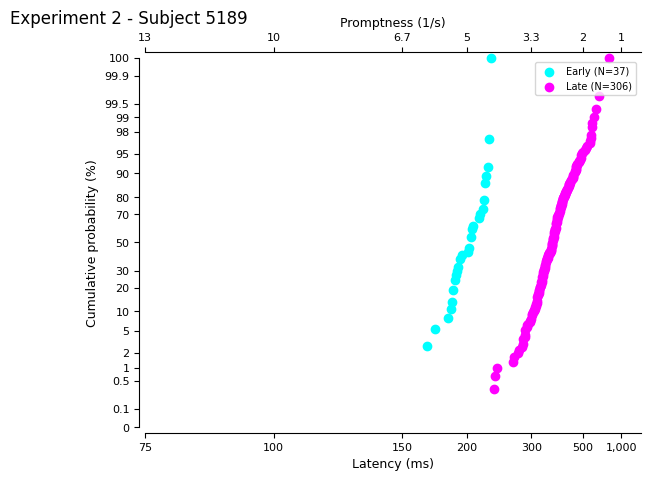

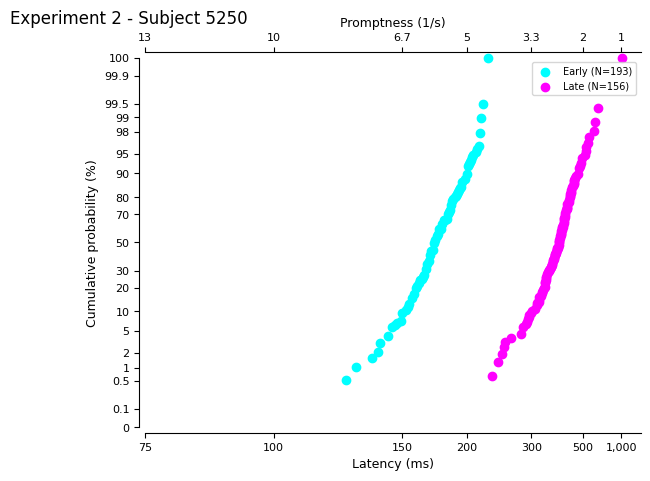

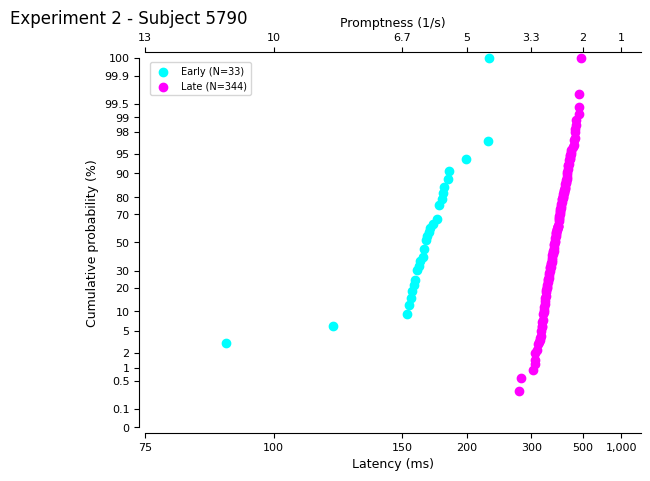

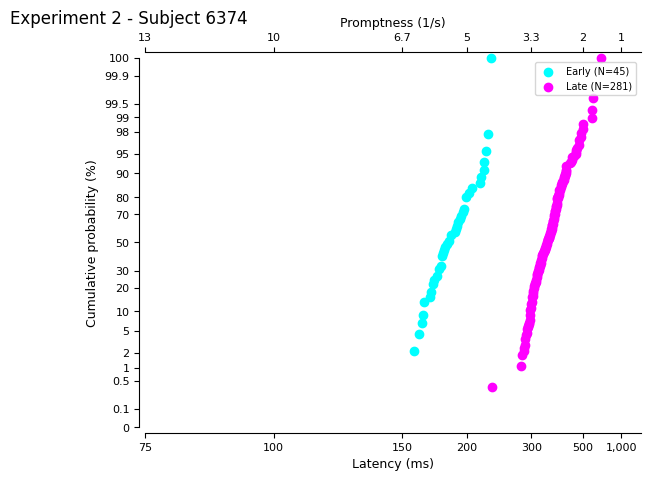

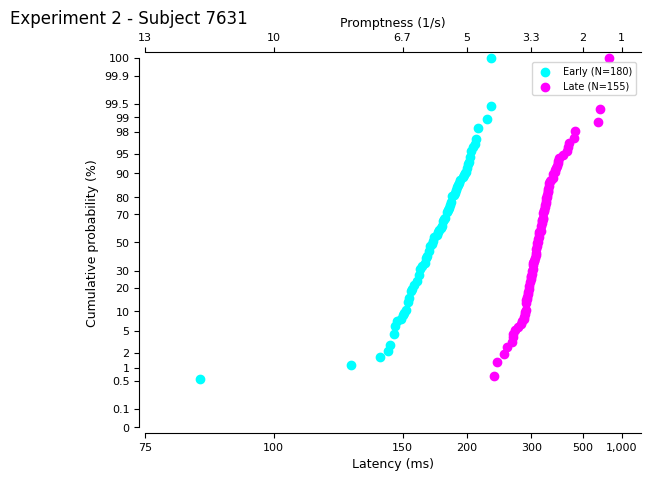

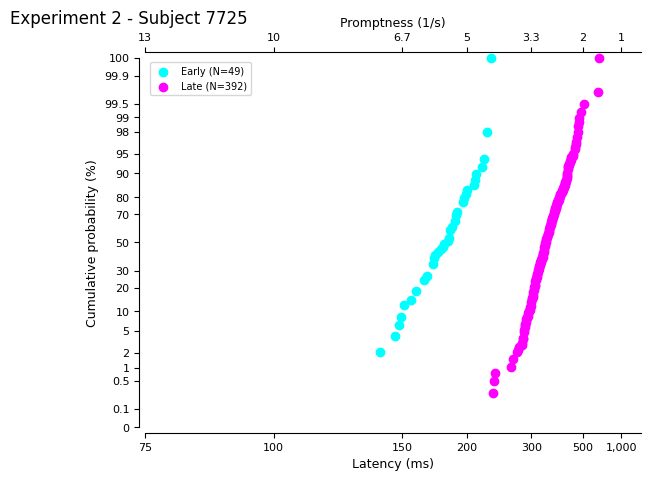

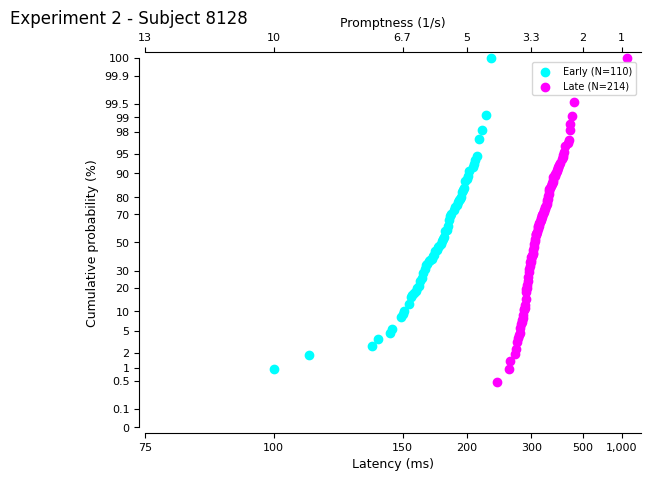

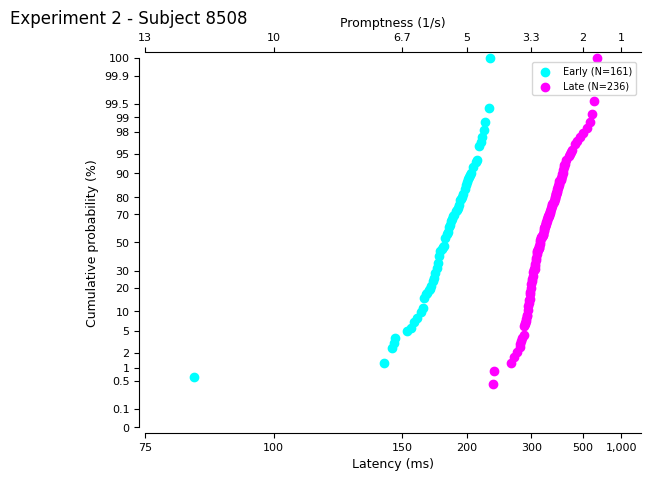

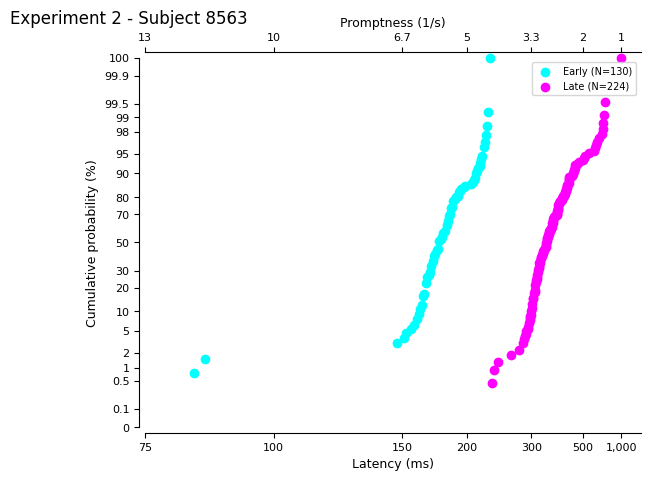

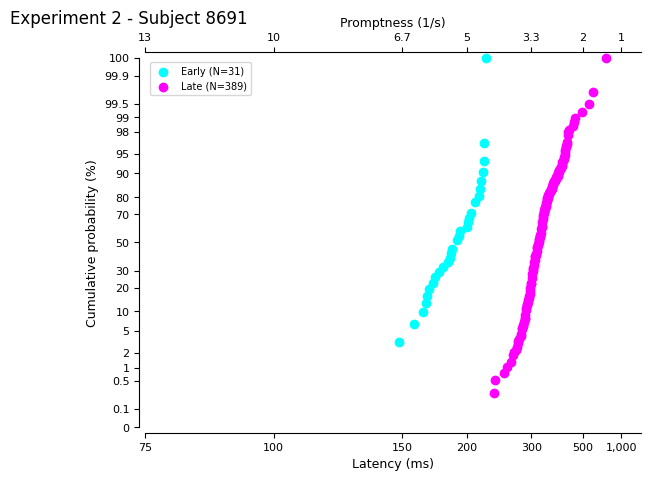

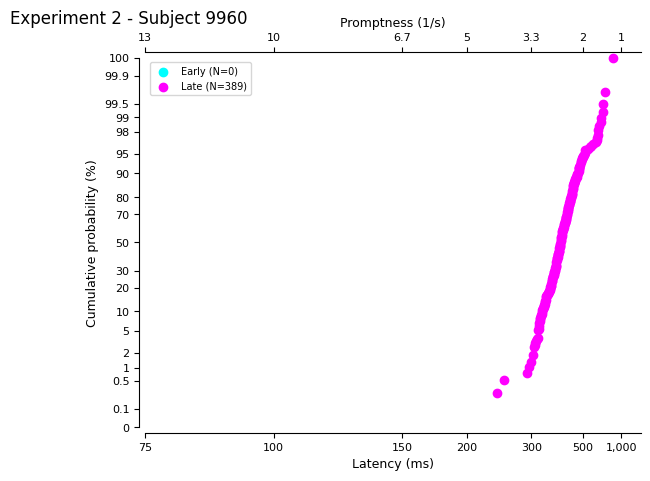

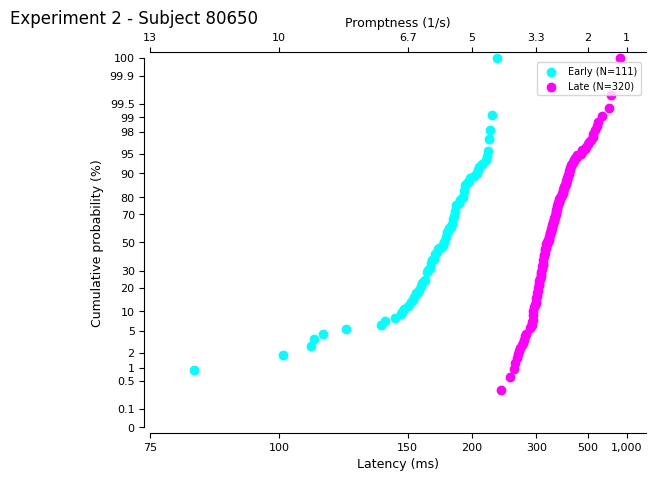

In [11]:
for exp in DATA["experiment"].unique():
    print(f"###\tExperiment {exp[-1]}\t###")
    exp_data = DATA.loc[DATA["experiment"] == exp]
    for subj in exp_data["subject"].unique():
        plot = pylater.ReciprobitPlot()
        for is_early in [True, False]:
            line_name = "Early" if is_early else "Late"
            line_color = COLORS[line_name]
            latencies = exp_data.loc[
                (exp_data["subject"] == subj) & (exp_data["is_early_saccade"] == is_early),
                "saccade_onset",
            ]
            latencies = (latencies / 1000.0).dropna()   # convert to seconds
            plot.plot_data(
                data=pylater.Dataset(name=line_name, rt_s=latencies,),
                label=f"{line_name} (N={len(latencies)})", color=line_color, plot_type='scatter',
            )
            plot.min_rt_s = min(plot.min_rt_s, latencies.min())
            plot.max_rt_s = max(plot.max_rt_s, latencies.max())
        plot.fig = plot.fig.suptitle(f"Experiment {exp[-1]} - Subject {subj}", y=0.98, x=0.1)
        plt.show()
        print()